<a href="https://colab.research.google.com/github/beatrizzzzz/Estudo-com-o-PERMA-Profiler/blob/main/graficos_tcc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Configuração global dos gráficos
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.edgecolor': '#444444',
    'axes.linewidth': 0.8,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

# Paleta de cores
AZUL    = '#2E6E9E'
VERDE   = '#3C9D6E'
LARANJA = '#E08A2B'
ROXO    = '#9B7FC0'
CINZA   = '#9AA3AB'

Gráficos: Gênero · Faixa etária · Escolaridade · Religião · Nível de religiosidade · Etnia/raça

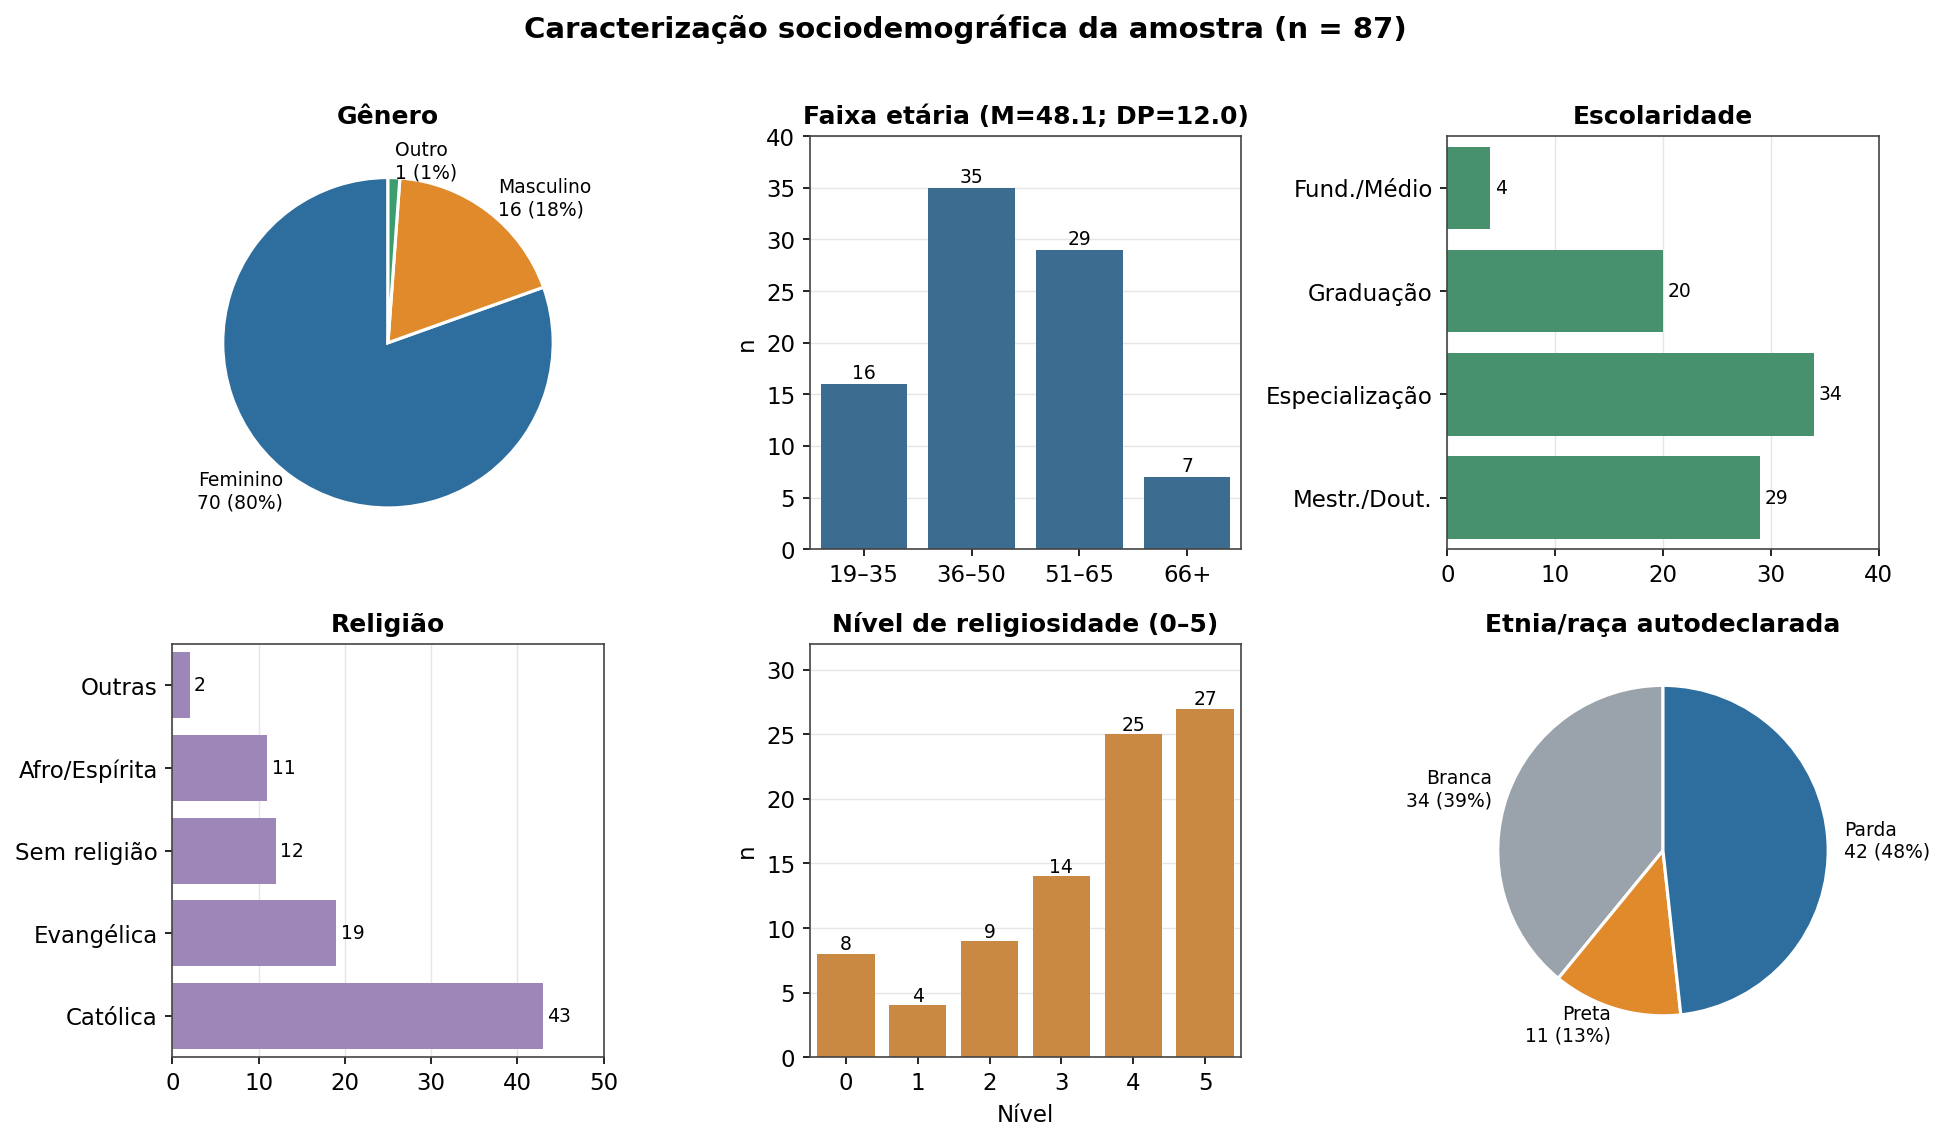

In [ ]:

# Gênero
gen_labels  = ['Feminino', 'Masculino', 'Outro']
gen_valores = [70, 16, 1]
gen_cores   = [AZUL, LARANJA, VERDE]

# Faixa etária
faixas    = ['19–35', '36–50', '51–65', '66+']
contagens = [16, 35, 29, 7]

# Escolaridade
esc_labels  = ['Fund./Médio', 'Graduação', 'Especialização', 'Mestr./Dout.']
esc_valores = [4, 20, 34, 29]

# Religião
rel_labels  = ['Outras', 'Afro/Espírita', 'Sem religião', 'Evangélica', 'Católica']
rel_valores = [2, 11, 12, 19, 43]

# Nível de religiosidade
niveis   = [0, 1, 2, 3, 4, 5]
religios = [8, 4, 9, 14, 25, 27]

# Etnia/raça
et_labels  = ['Branca', 'Preta', 'Parda']
et_valores = [34, 11, 42]
et_cores   = [CINZA, LARANJA, AZUL]

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
fig.suptitle('Caracterização sociodemográfica da amostra (n = 87)',
             fontsize=14, fontweight='bold', y=1.01)


#  1. Gênero (pizza)
ax = axes[0, 0]
ax.pie(
    gen_valores,
    labels=[f'{l}\n{v} ({100*v/87:.0f}%)' for l, v in zip(gen_labels, gen_valores)],
    colors=gen_cores,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 9},
)
ax.set_title('Gênero')


#  2. Faixa etária (barras verticais)
ax = axes[0, 1]
sns.barplot(x=faixas, y=contagens, color=AZUL, ax=ax)
for i, v in enumerate(contagens):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=9)
ax.set_title('Faixa etária (M=48.1; DP=12.0)')
ax.set_ylabel('n')
ax.set_ylim(0, 40)
ax.grid(axis='y', color='#E6E6E6', linewidth=0.7)
ax.set_axisbelow(True)


# 3. Escolaridade (barras horizontais)
ax = axes[0, 2]
sns.barplot(y=esc_labels, x=esc_valores, color=VERDE, orient='h', ax=ax)
for i, v in enumerate(esc_valores):
    ax.text(v + 0.4, i, str(v), va='center', fontsize=9)
ax.set_title('Escolaridade')
ax.set_xlim(0, 40)
ax.grid(axis='x', color='#E6E6E6', linewidth=0.7)
ax.set_axisbelow(True)


#  4. Religião (barras horizontais)
ax = axes[1, 0]
sns.barplot(y=rel_labels, x=rel_valores, color=ROXO, orient='h', ax=ax)
for i, v in enumerate(rel_valores):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=9)
ax.set_title('Religião')
ax.set_xlim(0, 50)
ax.grid(axis='x', color='#E6E6E6', linewidth=0.7)
ax.set_axisbelow(True)


# 5. Nível de religiosidade (barras verticais)
ax = axes[1, 1]
sns.barplot(x=[str(n) for n in niveis], y=religios, color=LARANJA, ax=ax)
for i, v in enumerate(religios):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=9)
ax.set_title('Nível de religiosidade (0–5)')
ax.set_xlabel('Nível')
ax.set_ylabel('n')
ax.set_ylim(0, 32)
ax.grid(axis='y', color='#E6E6E6', linewidth=0.7)
ax.set_axisbelow(True)


# 6. Etnia/raça (pizza)
ax = axes[1, 2]
ax.pie(
    et_valores,
    labels=[f'{l}\n{v} ({100*v/87:.0f}%)' for l, v in zip(et_labels, et_valores)],
    colors=et_cores,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 9},
)
ax.set_title('Etnia/raça autodeclarada')


plt.tight_layout()
plt.savefig('sociodemografico.png')
plt.show()

## 2. Heatmap — Correlações de Spearman entre as dimensões do PERMA

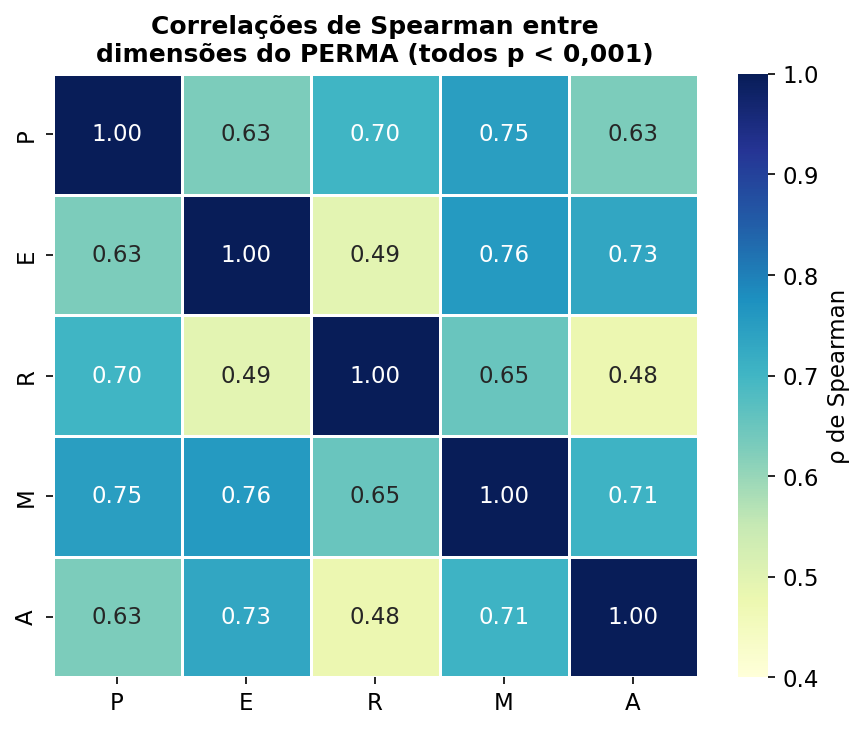

In [ ]:
# Matriz de correlações de Spearman
dados_corr = {
    'P': [1.00, 0.628, 0.702, 0.747, 0.628],
    'E': [0.628, 1.00,  0.495, 0.758, 0.732],
    'R': [0.702, 0.495, 1.00,  0.652, 0.478],
    'M': [0.747, 0.758, 0.652, 1.00,  0.706],
    'A': [0.628, 0.732, 0.478, 0.706, 1.00 ],
}
labels  = ['P', 'E', 'R', 'M', 'A']
df_corr = pd.DataFrame(dados_corr, index=labels)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    df_corr,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    vmin=0.4,
    vmax=1.0,
    linewidths=0.5,
    cbar_kws={'label': 'ρ de Spearman'},
    ax=ax,
)
ax.set_title(
    'Correlações de Spearman entre\ndimensões do PERMA (todos p < 0,001)',
    fontsize=12,
)
plt.tight_layout()
plt.savefig('heatmap_perma.png')
plt.show()